# 09 · Active learning and closed-loop optimisation

Experiments are expensive; the candidate pool is large. Each round the platform must decide
**which ~100 of 100 000 candidates to measure next**. The decision is made by an *acquisition
function* applied to the surrogate model's prediction $\mu(x)$ and uncertainty $\sigma(x)$, after
domain *constraints* have removed infeasible candidates.

```text
       ┌──────────── round r ────────────┐
data ─►│ train surrogate ─► predict pool ─►│ constraints ─► acquisition ─► top-k batch
 ▲     └──────────────────────────────────┘                                   │
 │                                                                             ▼
 └────────────── new immutable round r+1 ◄──────────── run experiments (oracle / lab)
```

This notebook runs that loop for several rounds against the synthetic oracle, using the
library functions directly (the Dagster assets in `orchestration/` call the same functions),
and compares acquisition strategies by **learning efficiency**: how fast the best measured
design approaches the true optimum.

## Conceptual model

**Exploitation vs exploration.** Measuring where $\mu$ is highest refines what we already believe;
measuring where $\sigma$ is highest reduces uncertainty that might hide a better optimum. Every
acquisition function is a policy for this trade-off:

| Acquisition | Score $a(x)$ | Knob / property |
|---|---|---|
| greedy | $\mu(x)$ | pure exploitation; gets stuck |
| uncertainty sampling | $\sigma(x)$ | pure exploration; good for *model accuracy*, not for optimisation |
| UCB | $\mu(x) + \beta\,\sigma(x)$ | $\beta$ = optimism; regret bounds for GPs with growing $\beta$ |
| Expected Improvement | $\mathbb E[\max(f(x) - f^\*, 0)]$ | no knob; favours $\mu$ near/above incumbent $f^\*$ with high $\sigma$ |
| Thompson sampling | one draw $\tilde f(x) \sim \mathcal N(\mu, \sigma^2)$ | randomised; batches diversify naturally |

**EI in closed form.** If $f(x) \sim \mathcal N(\mu, \sigma^2)$ and $I = \max(f - f^\*, 0)$, with
$z = (\mu - f^\*)/\sigma$:

$$\mathbb E[I] = \int_{f^\*}^\infty (f - f^\*)\,\tfrac{1}{\sigma}\varphi\!\big(\tfrac{f-\mu}{\sigma}\big)\,df
= (\mu - f^\*)\,\Phi(z) + \sigma\,\varphi(z),$$

(substitute $u = (f-\mu)/\sigma$ and use $\int_{-z}^\infty u\,\varphi(u)\,du = \varphi(z)$).
This is `active_learning.acquisition.expected_improvement`.

**Relation to Bayesian optimisation.** BO is exactly this loop with a Gaussian-process surrogate,
whose posterior $(\mu, \sigma)$ is exact under its prior. Here the surrogate is a neural network
and $\sigma$ comes from MC dropout — cheaper and scalable to 10⁵ candidates × 32 features, but
only a rough, often mis-calibrated uncertainty (notebook 07 §5–6). The loop, constraints and
bookkeeping are the same.

**Batch acquisition.** Labs run experiments in plates/batches. Taking the top-$k$ of a
one-point acquisition picks $k$ near-duplicates around one mode. Remedies: Thompson sampling
(independent draws), local penalisation / diversity radius (`select_batch(diversity_radius=...)`),
or "kriging believer" fantasies (re-fit after each pick).

In [1]:
import os, sys, tempfile, time, warnings
from pathlib import Path

os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
os.environ.setdefault("MERGE_LOG_LEVEL", "WARNING")   # keep structlog output out of the notebook
os.environ.setdefault("RAY_DEDUP_LOGS", "1")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 80, "figure.figsize": (7.5, 3.6), "axes.grid": True,
                     "grid.alpha": 0.3})

# Every artifact this notebook creates lives in a fresh temp dir -- never in the repo's
# data/, artifacts/ or mlflow.db.
WORK = Path(tempfile.mkdtemp(prefix="nb09_"))
T0 = time.perf_counter()
print("workspace:", WORK)

workspace: /var/folders/vx/0jy3t_qx56q4d0qpnmgs008r0000gn/T/nb09_mf_j12yf


  greedy picks x = 0.28
 UCB β=3 picks x = 0.85
      EI picks x = 0.22


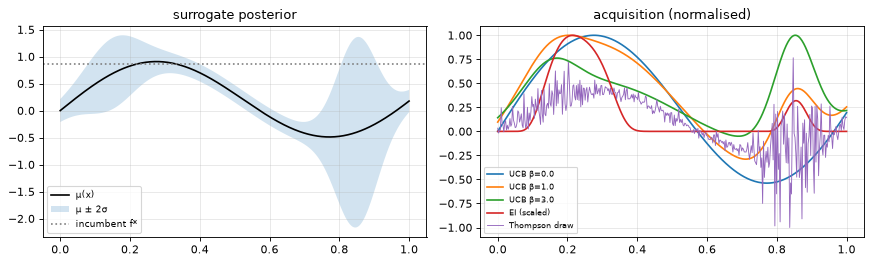

In [2]:
from bci_platform.active_learning import (apply_constraints, default_constraints, expected_improvement,
                                            MaxCost, select_batch, thompson, ucb)
from bci_platform.config import PlatformConfig
from bci_platform.data.datasets import ArrayDataset, RoundStore, train_val_split
from bci_platform.data.generation import (generate_candidate_pool, initial_observations, make_oracle,
                                            measure_candidates, pool_features)
from bci_platform.evaluation import rmse
from bci_platform.inference.batch import predict_pool_local
from bci_platform.training import Trainer

# 1-D illustration of the acquisition functions on a made-up posterior
x = np.linspace(0, 1, 400)
mu = np.sin(6 * x) * 0.8 + 0.4 * x
sigma = 0.08 + 0.8 * np.exp(-((x - 0.85) / 0.08) ** 2) + 0.25 * np.exp(-((x - 0.15) / 0.1) ** 2)
best = mu.max() - 0.05
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(x, mu, "k", label="μ(x)"); axes[0].fill_between(x, mu - 2 * sigma, mu + 2 * sigma, alpha=0.2, label="μ ± 2σ")
axes[0].axhline(best, ls=":", c="gray", label="incumbent f*"); axes[0].legend(fontsize=8); axes[0].set_title("surrogate posterior")
for beta in (0.0, 1.0, 3.0):
    s = ucb(mu, sigma, beta); axes[1].plot(x, s / np.abs(s).max(), label=f"UCB β={beta}")
ei = expected_improvement(mu, sigma, best); axes[1].plot(x, ei / ei.max(), label="EI (scaled)")
th = thompson(mu, sigma, seed=0); axes[1].plot(x, th / np.abs(th).max(), lw=0.8, label="Thompson draw")
for name, s in (("greedy", mu), ("UCB β=3", ucb(mu, sigma, 3.0)), ("EI", ei)):
    print(f"{name:>8} picks x = {x[np.argmax(s)]:.2f}")
axes[1].set_title("acquisition (normalised)"); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

Greedy and EI stay near the known peak (EI rewards *likely* improvements over the incumbent),
while UCB with a large β jumps to the very uncertain region near $x = 0.85$, where a much
higher value is plausible but not likely. The acquisition function *is* the exploration policy.

## 1 · The closed loop, round by round

Setup (small, CPU-friendly): a 20 000-candidate pool, a random initial design of 60 measured
experiments (round 0), then 6 rounds of 20 experiments. Every round is written to a
write-once `RoundStore`, exactly like the pipeline's `new_experimental_results` asset.

We measure *learning efficiency* with the **simple regret** of the best experiment run so far,
using the oracle's noise-free mean (which the model never sees):

$$r_t = f(x^\star) - \max_{x \in \mathcal D_t} f(x),\qquad x^\star = \arg\max_{x\in\text{pool}} f(x).$$

In [3]:
cfg = PlatformConfig.for_tests(WORK, **{
    "data.pool_size": 20_000, "data.initial_observations": 60, "data.batch_size_per_round": 20,
    "model.hidden_dims": [64, 64], "training.epochs": 25, "evaluation.mc_samples": 20,
    "active_learning.beta": 1.0})
pool = generate_candidate_pool(cfg)
oracle = make_oracle(cfg)
X_pool = pool_features(pool, cfg.data.n_features)
f_true = pd.Series(oracle.mean(X_pool), index=pool.candidate_id)     # hidden truth, diagnostics only
f_star = f_true.max()
test_ids = pool.candidate_id.sample(2000, random_state=0).to_numpy()  # fixed random probe set
print(f"pool: {len(pool)} candidates; true optimum f* = {f_star:.2f}; "
      f"pool mean f = {f_true.mean():.2f}; 99th pct = {f_true.quantile(0.99):.2f}")

pool: 20000 candidates; true optimum f* = 6.68; pool mean f = 1.48; 99th pct = 5.43


In [4]:
N_ROUNDS = 6

def pick_random(preds, observed, round_id, seed):
    # Random baseline: same constraints, uniform choice among feasible candidates.
    feasible = apply_constraints(pool, default_constraints(cfg.active_learning, observed)).kept
    rng = np.random.default_rng([seed, round_id])
    return feasible.iloc[rng.choice(len(feasible), cfg.data.batch_size_per_round, replace=False)]

def run_campaign(strategy, seed=0):
    c = cfg.with_overrides(seed=seed)
    store = RoundStore(WORK / f"{strategy}_s{seed}")
    store.write_round(0, initial_observations(pool, oracle, n=cfg.data.initial_observations, seed=seed),
                      provenance={"strategy": "random_initial_design"})
    hist = []
    for r in range(1, N_ROUNDS + 2):
        frame = store.training_frame()
        observed = store.observed_ids()
        best_f = f_true[frame.experiment_id].max()
        tr, va = train_val_split(frame, 0.2, seed)
        res = Trainer(c).train(ArrayDataset.from_frame(tr), ArrayDataset.from_frame(va),
                               checkpoint_dir=store.root / f"ckpt_{r}")
        preds = predict_pool_local(res.checkpoint_path, pool, mc_samples=20, seed=r)
        p = preds.set_index("candidate_id")
        hist.append({"strategy": strategy, "seed": seed, "round": r - 1, "n_obs": len(frame),
                     "best_true_f": best_f, "simple_regret": f_star - best_f,
                     "probe_rmse": rmse(f_true[test_ids], p.pred_mean[test_ids]),
                     "best_measured_y": frame.response.max()})
        if r == N_ROUNDS + 1:
            break                                           # last model is only evaluated
        if strategy == "random":
            batch = pick_random(preds, observed, r, seed)
        else:
            batch = select_batch(pool, preds, observed, c, round_id=r, strategy=strategy,
                                 best_observed=float(frame.response.max()),
                                 model_version=f"{strategy}-{r}").selected
        recs = measure_candidates(batch, oracle, round_id=r, seed=seed,
                                  provenance={"strategy": strategy})
        store.write_round(r, recs, provenance={"strategy": strategy, "model_version": f"{strategy}-{r}"})
    return pd.DataFrame(hist), store, preds

t0 = time.perf_counter()
runs = {}
for strategy in ("random", "greedy", "ucb", "ei", "thompson"):
    for seed in (0, 1):
        runs[(strategy, seed)] = run_campaign(strategy, seed)
history = pd.concat([h for h, _, _ in runs.values()], ignore_index=True)
print(f"10 campaigns x {N_ROUNDS} rounds in {time.perf_counter() - t0:.0f}s")
(history[history["round"] == N_ROUNDS]
 .groupby("strategy")[["n_obs", "best_true_f", "simple_regret", "probe_rmse"]].mean()
 .sort_values("simple_regret"))

10 campaigns x 6 rounds in 20s


,n_obs,best_true_f,simple_regret,probe_rmse
strategy,,,,
ei,180.0,6.5296,0.1465,1.0488
ucb,180.0,6.5296,0.1465,1.0430
greedy,180.0,6.3831,0.2930,1.1123
thompson,180.0,6.3831,0.2930,1.0741
random,180.0,5.8654,0.8107,0.7979


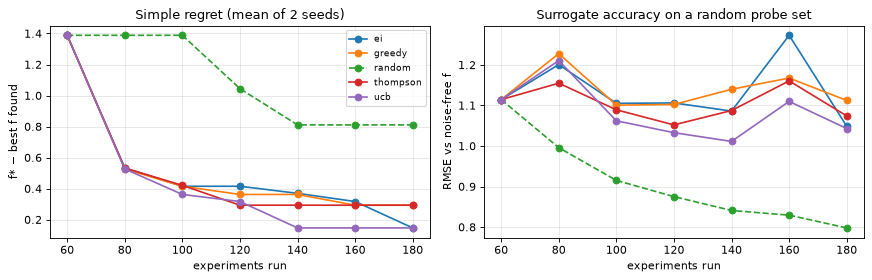

In [5]:
mean_hist = history.groupby(["strategy", "round"]).mean(numeric_only=True).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for strategy, g in mean_hist.groupby("strategy"):
    ls = "--" if strategy == "random" else "-"
    axes[0].plot(g.n_obs, g.simple_regret, ls, marker="o", label=strategy)
    axes[1].plot(g.n_obs, g.probe_rmse, ls, marker="o", label=strategy)
axes[0].set(xlabel="experiments run", ylabel="f* − best f found", title="Simple regret (mean of 2 seeds)")
axes[1].set(xlabel="experiments run", ylabel="RMSE vs noise-free f",
            title="Surrogate accuracy on a random probe set")
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

**Reading the plots.** Model-guided strategies find far better designs than random selection
with the same budget (left) — that is the whole point of the closed loop. The right panel shows
the flip side: acquisition spends the budget where the optimum is, so global model accuracy on a
*random* probe set improves more slowly than one might hope (and can even be worse than for
random selection). Optimisation and model accuracy are different objectives. With 2 seeds and
6 small rounds the ranking among UCB / EI / Thompson / greedy is noisy — see the exercise.

## 2 · Constraints are applied before ranking

Domain constraints (`active_learning.constraints`) encode lab knowledge — safe operating ranges,
budget, "do not repeat" — separately from the model. They are applied *before* acquisition so
infeasible candidates never consume batch slots, and `ConstraintReport` records why each one
was rejected.

In [6]:
hist_ucb, store_ucb, preds_ucb = runs[("ucb", 0)]
observed = store_ucb.observed_ids()
cons = default_constraints(cfg.active_learning, observed) + [MaxCost(1.0)]
report = apply_constraints(pool, cons)
print(pd.Series(report.summary()["rejected_by"], name="rejected_by"))
print(f"feasible: {report.n_kept} of {report.n_input}")

capped = select_batch(pool, preds_ucb, observed, cfg, round_id=N_ROUNDS + 1,
                      extra_constraints=[MaxCost(1.0)])
free = select_batch(pool, preds_ucb, observed, cfg, round_id=N_ROUNDS + 1)
print(f"mean cost of UCB batch: unconstrained {free.selected.cost.mean():.2f} "
      f"-> with MaxCost(1.0) {capped.selected.cost.mean():.2f}; "
      f"true mean f of batch: {f_true[free.candidate_ids].mean():.2f} -> {f_true[capped.candidate_ids].mean():.2f}")
print("selection_hash (artifact version):", capped.selection_hash[:16])

exclude_observed     180
feature_bounds         0
max_cost            9523
Name: rejected_by, dtype: int64
feasible: 10401 of 20000
mean cost of UCB batch: unconstrained 1.34 -> with MaxCost(1.0) 0.84; true mean f of batch: 5.15 -> 5.18
selection_hash (artifact version): 7310967c4c00f319


## 3 · Batch acquisition and diversity

Top-$k$ UCB concentrates the batch. `select_batch(diversity_radius=r)` walks the ranking and skips
a candidate within Euclidean distance $r$ of one already chosen — a cheap local-penalisation
heuristic. Compare batch spread and quality:

In [7]:
from scipy.spatial.distance import pdist

rows = []
for label, kwargs in (("UCB top-k", {}), ("UCB + diversity r=6.5", {"diversity_radius": 6.5}),
                      ("Thompson", {"strategy": "thompson"})):
    sel = select_batch(pool, preds_ucb, observed, cfg, round_id=N_ROUNDS + 1, **kwargs)
    Xs = sel.selected.filter(regex=r"^f\d+$").to_numpy()
    rows.append({"batch": label, "mean pairwise dist": pdist(Xs).mean(), "min pairwise dist": pdist(Xs).min(),
                 "mean true f": f_true[sel.candidate_ids].mean(), "max true f": f_true[sel.candidate_ids].max(),
                 "skipped for diversity": sel.summary["n_diversity_skipped"]})
print(f"(typical distance between two random pool candidates: {pdist(X_pool[:300]).mean():.1f})")
pd.DataFrame(rows).set_index("batch")

(typical distance between two random pool candidates: 7.9)


,mean pairwise dist,min pairwise dist,mean true f,max true f,skipped for diversity
batch,,,,,
UCB top-k,7.4053,5.1640,5.1483,5.9817,0
UCB + diversity r=6.5,8.1101,6.5826,5.1720,6.0749,20
Thompson,7.6041,5.1190,5.0818,6.0089,0


## 4 · Selection bias

Actively acquired rounds are, by construction, **not** a random sample of the pool. Two
consequences for everything downstream:

final UCB model: RMSE on its acquired rows 0.426 (training rows!) vs random probe set 1.078


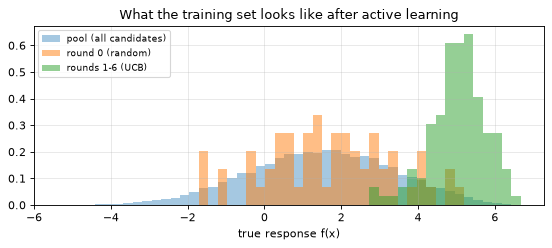

In [8]:
frame = store_ucb.training_frame()
is_al = frame.round_id > 0
pred_on_frame = preds_ucb.set_index("candidate_id").pred_mean[frame.experiment_id].to_numpy()
print(f"final UCB model: RMSE on its acquired rows {rmse(frame.response[is_al], pred_on_frame[is_al]):.3f} "
      f"(training rows!) vs random probe set {hist_ucb.probe_rmse.iloc[-1]:.3f}")

fig, ax = plt.subplots(figsize=(7, 3.2))
bins = np.linspace(f_true.min(), f_true.max(), 50)
ax.hist(f_true, bins=bins, density=True, alpha=0.4, label="pool (all candidates)")
ax.hist(f_true[frame.experiment_id[~is_al]], bins=bins, density=True, alpha=0.5, label="round 0 (random)")
ax.hist(f_true[frame.experiment_id[is_al]], bins=bins, density=True, alpha=0.5, label=f"rounds 1-{N_ROUNDS} (UCB)")
ax.set(xlabel="true response f(x)", title="What the training set looks like after active learning")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

1. **Training distribution drifts** toward promising regions: the model becomes better there
   and relatively worse elsewhere. Metrics on acquired rows describe the acquired region only.
2. **Evaluation must be designed for it** — keep the random round 0 (or periodic random
   "sentinel" experiments) as an unbiased reference; evaluate prospectively on the next round;
   never pool acquired rows into a "random" test set (notebook 07).
3. **Feedback loops** — a biased model selects biased data that confirms it. Exploration
   ($\beta > 0$, Thompson, random sentinels) is the guard rail.

## Connection to this repository

| Concept | Where |
|---|---|
| UCB / EI / Thompson / greedy / uncertainty, deterministic ranking | `src/bci_platform/active_learning/acquisition.py` → `ucb`, `expected_improvement`, `thompson`, `acquisition_scores`, `rank_candidates` |
| domain constraints, rejection audit | `src/bci_platform/active_learning/constraints.py` → `FeatureBounds`, `MaxCost`, `ExcludeIds`, `apply_constraints`, `ConstraintReport` |
| one decision step, diversity, versioned selection | `src/bci_platform/active_learning/loop.py` → `select_batch`, `SelectionResult.selection_hash`, `write_selection` |
| pool scoring with MC dropout | `src/bci_platform/inference/batch.py` → `predict_pool` (Ray) / `predict_pool_local` |
| running the "experiment", new immutable round | `src/bci_platform/data/generation.py` → `measure_candidates`; `data/datasets.py` → `RoundStore.write_round` |
| the same loop as Dagster assets | `candidate_predictions → selected_experiments → new_experimental_results` in `src/bci_platform/orchestration/`, `make closed-loop` |

## Failure modes

* **Over-exploitation** — greedy/low-β selection collapses onto one mode; regret plateaus.
* **Mis-calibrated σ** — MC-dropout σ can be smallest exactly where the model is wrong
  (notebook 07 §6); UCB/EI then under-explore. Random sentinels detect this.
* **Redundant batches** — top-k of a one-point acquisition wastes a plate on near-duplicates.
* **Leaking constraints into the model** — "the model learned not to pick expensive designs" is
  not auditable; constraints must remain explicit, versioned predicates.
* **Non-reproducible selections** — ties, unseeded Thompson draws, or unordered joins make the
  batch depend on row order. `rank_candidates` breaks ties by `candidate_id`; `select_batch`
  seeds randomised strategies with `cfg.seed + round_id` and hashes the result.
* **Evaluating on acquired data** — selection bias makes those metrics optimistic or simply
  about a different population.

## Exercise

1. Increase to 5 seeds and plot mean ± standard error of simple regret per strategy. Which
   differences survive? (Budget: ~1 s per round per campaign.)
2. Sweep β ∈ {0, 0.5, 1, 2, 4} for UCB. Plot final regret and final probe RMSE against β — the
   exploration/exploitation trade-off as a curve.
3. Add a "sentinel" policy: 90 % UCB + 10 % random per batch. How does it change probe RMSE and
   regret?

In [9]:
import shutil
shutil.rmtree(WORK, ignore_errors=True)
print(f"done in {time.perf_counter() - T0:.1f}s; workspace removed (no Ray used in this notebook)")

done in 22.0s; workspace removed (no Ray used in this notebook)
